In [30]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk import tokenize
import plotly.express as px
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_samples
N_CLUSTERS = 8
load_dotenv("../.env")
ROOT = os.getenv("PROJECT_ROOT")


In [31]:
nltk.download('all')


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /Users/cleberfcarvalho/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /Users/cleberfcarvalho/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /Users/cleberfcarvalho/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /Users/cleberfcarvalho/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /Users/cleberfcarvalho/nltk_data...
[nltk_data]    |   Package averaged_perce

True

In [32]:
path_data = f'{ROOT}/data/dev/sygnaly_dev_clean_3000.csv'
df = pd.read_csv(path_data)
display(df.head())


,title,content
0,Rosyjskie MSZ cofnęło akredytację. Dziennikark...,Czytaj więcej w raporcie: Rosja napadła na Uk...
1,Tragedia na paradzie bożonarodzeniowej. Mężczy...,Na filmach wideo pokazywanych przez amerykańs...
2,Broniarz: Od soboty ZNP zawiesza strajk,– Dzisiaj w Sejmie mamy do czynienia z próbą...
3,Szydło o zakłóconym spotkaniu: Tusk uruchomił ...,– To jest właśnie pomysł Tuska. Dzielenie Pol...
4,USA zniszczy swoje zimnowojenne zapasy broni c...,– Jesteśmy gotowi wypełnić przyjęte zobowia...


In [33]:
df['content'][1]

'Na filmach wideo pokazywanych przez amerykańskie stacje telewizyjne oraz publikowanych w mediach społecznościowych widać czerwonego SUV-a marki Ford wjeżdżającego z dużą prędkością w paradę maszerującą ulicami Waukesha, miejscowości położonej na przedmieściach Milwaukee.   Uderzając w ludzi kierowca nie hamował. Świadkowie mówią także o strzałach z broni palnej, ale nie jest jasne, czy broni użył kierowca czy policja.    „Policja z Waukesha jest posiadaniu samochodu sprawcy. Trwa dochodzenie. Ofiary są przewożone karetkami do szpitali. To bardzo tragiczne zdarzenie” – mówił szef policji z Waukesha Dan Thompson. Dan Thompson później poinformował, że „podejrzana osoba” została zatrzymana, podobnie jak jej pojazd. Dodał, że motyw działania sprawcy jest na razie nieznany i nie wiadomo jeszcze, czy atak był aktem terroryzmu.    Na jednym z filmów opublikowanych w mediach społecznościowych widać jak policja prawdopodobnie strzelała do pojazdu, który przejec

In [34]:
all_words = [text for text in df['content']]
print(len(all_words))

2887


In [35]:
all_words = ' '.join([text for text in df['content']])
print(all_words)

 Operacja będzie w stu procentach refundowana przez NFZ. Na ekranie pojawiły się mianowicie produkcje, które można podejrzewać o propagandowy charakter, i – w znacznym stopniu – wtórne formalnie. Nie kłóci się to z zasadniczym założeniem selekcjonerów – pokaz miał przede wszystkim dostarczyć widzom informacji o obyczajach Irańczyków i zaprezentować tamtejsze kino gatunków. Ten cel został zrealizowany wzorowo.   Ale poza tym, co zobaczyliśmy?  „Grzesznicy”, kryminał z elementami filmu noir, wraz z pojawieniem się na ekranie starego doświadczonego detektywa zyskuje niezamierzone efekty komediowe. Pewny siebie policjant, jak Frank Drebin tonem wyroczni wygłasza przed młodszym kolegą maksymy typu: „po pierwsze nigdy się nie mylę; jak myślisz, że się mylę, patrz punkt pierwszy”. Albo pyta z zimną krwią, jedząc zamówiony wcześniej owczy mózg: „to jest mózg owcy, a gdzie jest twój?”. Irański odpowiednik bohatera  „Nagiej broni”  jest zdecydowanie bardziej agr

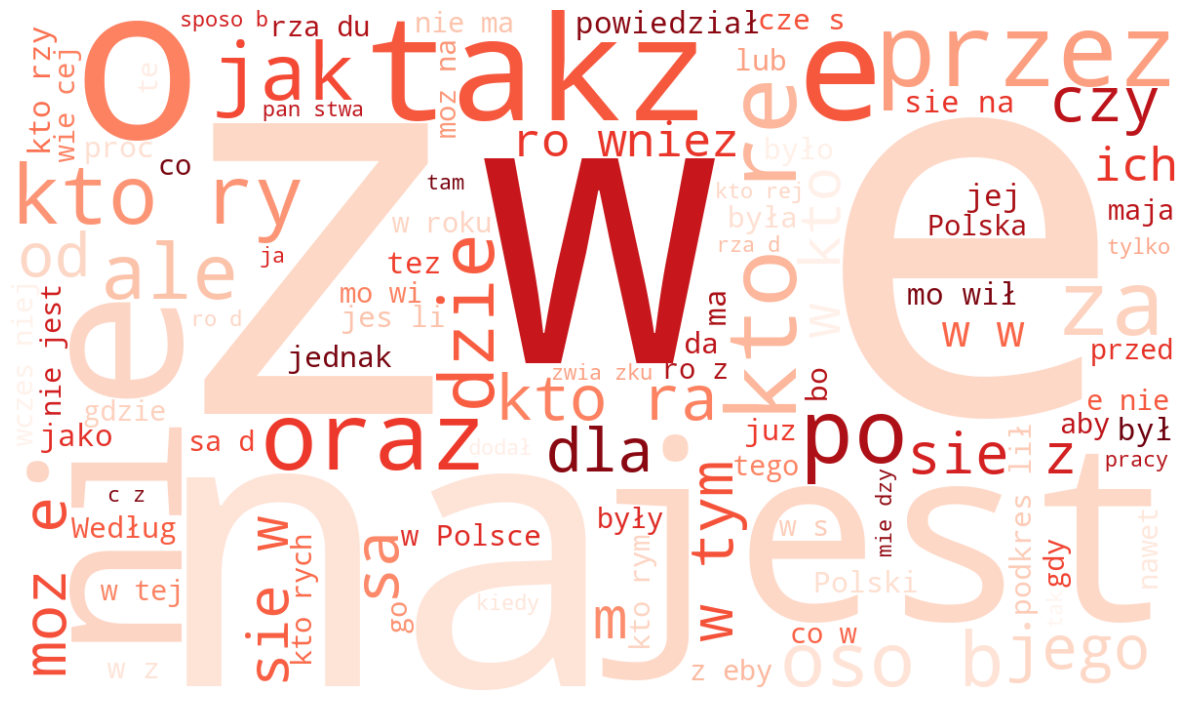

In [36]:
word_cloud = WordCloud(max_words=100,
                       background_color="white",
                       colormap="Reds", 
                       width=1200,
                       height=700,
                       random_state=48).generate(all_words)

plt.figure(figsize=(12,8))
plt.imshow(word_cloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

In [37]:
token_space = tokenize.WhitespaceTokenizer()
token_statment = token_space.tokenize(all_words)


In [38]:
frequency_words = nltk.FreqDist(token_statment)
frequency_words

FreqDist({'w': 24113, '–': 13628, 'i': 13200, 'na': 12307, 'z': 11579, 'że': 9868, 'się': 8733, 'do': 8553, 'nie': 6588, 'o': 5050, ...})

In [39]:
df_frequency = pd.DataFrame({'Word': list(frequency_words.keys()),
                             'Frequency': list(frequency_words.values())})
df_frequency.head()

,Word,Frequency
0,Czytaj,76
1,więcej,277
2,w,24113
3,raporcie:,19
4,Rosja,185


In [40]:
df_top10_words = df_frequency.nlargest(columns = 'Frequency', n =10)

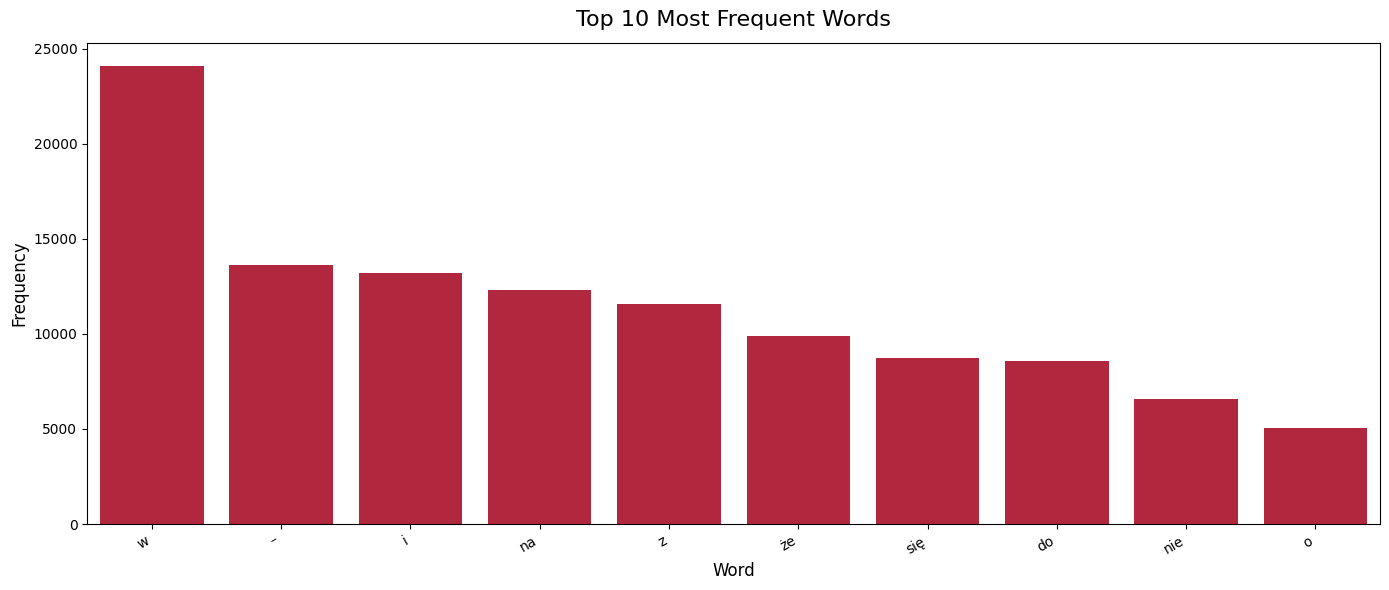

In [41]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=df_top10_words,
    x="Word",
    y="Frequency",
    color="#C8102E"
)
ax.set_title("Top 10 Most Frequent Words", fontsize=16, pad=12)
ax.set_xlabel("Word", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [42]:
word_cloud = WordCloud(
    max_words=100,
    background_color="white",
    colormap="Reds",
    width=1200,
    height=700,
    random_state=42
).generate(all_words)

wordcloud_array = np.array(word_cloud)

fig = px.imshow(wordcloud_array)
fig.update_layout(
    font=dict(
        family="Roboto",
        size=14,
        color="#2c3e50"
    ),
    title=dict(
        text="<b>Word Cloud — Overview</b>\n",
        x=0.5,
        xanchor='center',
        font=dict(size=20)
    ),
    coloraxis_showscale=False,
    margin=dict(l=0, r=0, t=40, b=0),
    plot_bgcolor="#f8f9fa",
    paper_bgcolor="#f8f9fa"

)
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

In [43]:
fig = px.bar(
    df_top10_words.sort_values("Frequency"),
    x="Frequency",
    y="Word",
    orientation="h",
    text="Frequency",
    color_discrete_sequence=["#C8102E"]
)

fig.update_layout(
    title=dict(
        text="<b>Top 10 Most Frequent Terms</b>",
        x=0.5,
        xanchor="center",
        font=dict(size=22)
    ),
    font=dict(
        family="Roboto, sans-serif",
        size=14,
        color="#2c3e50"
    ),
    xaxis_title="Frequency",
    yaxis_title=None,  # remove redundância
    template="plotly_white",
    margin=dict(l=40, r=20, t=70, b=40)
)

fig.update_traces(
    textposition="outside",
    textfont=dict(size=12),
    cliponaxis=False  # evita cortar os números
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#e5e7eb",
    zeroline=False
)

fig.update_yaxes(
    showgrid=False
)

fig.show()

In [44]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['content'])
kmeans = KMeans(
    n_clusters = N_CLUSTERS,
    random_state = 48,
    n_init= "auto"
).fit(X)

In [45]:
df['cluster'] = kmeans.labels_

In [46]:
display(df.head())

,title,content,cluster
0,Rosyjskie MSZ cofnęło akredytację. Dziennikark...,Czytaj więcej w raporcie: Rosja napadła na Uk...,0
1,Tragedia na paradzie bożonarodzeniowej. Mężczy...,Na filmach wideo pokazywanych przez amerykańs...,0
2,Broniarz: Od soboty ZNP zawiesza strajk,– Dzisiaj w Sejmie mamy do czynienia z próbą...,5
3,Szydło o zakłóconym spotkaniu: Tusk uruchomił ...,– To jest właśnie pomysł Tuska. Dzielenie Pol...,4
4,USA zniszczy swoje zimnowojenne zapasy broni c...,– Jesteśmy gotowi wypełnić przyjęte zobowia...,0


In [47]:
terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_
top_n = 10
for i in range(kmeans.n_clusters):
    top_indices = centroids[i].argsort()[-top_n:][::-1]
    top_words = [terms[j] for j in top_indices]

    print(f'\nCluster {i+1}:')
    print(', '.join(top_words))


Cluster 1:
na, do, sie, nie, kto, ci, jest, to, po, przez

Cluster 2:
na, sawczenko, sie, ukrain, ukrainy, kwietnia, wiera, nie, samochodzie, ukraine

Cluster 3:
na, nie, sie, do, to, kto, jest, ci, po, moz

Cluster 4:
sa, se, do, na, nie, sie, kto, ci, du, przez

Cluster 5:
na, sie, do, nie, kto, to, jest, ci, po, sa

Cluster 6:
na, nie, sie, do, to, kto, jest, ci, po, jak

Cluster 7:
szkoły, na, do, sie, ci, zaje, lub, moz, oraz, nalez

Cluster 8:
na, nie, po, sie, to, do, tusk, rosji, rosja, mo


In [48]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

fig = px.scatter(
    x=X_reduced[:, 0],
    y=X_reduced[:, 1],
    color=df["cluster"].astype(str),
    title="<b>Cluster Visualization (PCA Projection)</b>",
    labels={
        "x": "Principal Component 1",
        "y": "Principal Component 2",
        "color": "Cluster"
    },
    opacity=0.75
)

fig.update_layout(
    font=dict(
        family="Roboto, sans-serif",
        size=14,
        color="#2c3e50"
    ),
    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(size=22)
    ),
    template="plotly_white",
    margin=dict(l=40, r=40, t=70, b=40),
    legend_title_text="Cluster"
)

fig.update_traces(
    marker=dict(
        size=6,
        line=dict(width=0.5, color="white")
    )
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#e5e7eb",
    zeroline=False
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="#e5e7eb",
    zeroline=False
)

fig.show()


In [49]:
metric_inertia = kmeans.inertia_
print(f"Inertia: {metric_inertia:.2f}")

Inertia: 1138054.16


In [51]:
metric_silhouete = silhouette_samples(X, kmeans.labels_)
print(f"Silhouette Score: {metric_silhouete.mean()}")

Silhouette Score: 0.07691408351508122
